## Model Evaluation & Error Analysis

## Mục tiêu
 - Đánh giá hiệu suất mô hình tốt nhất
 - Phân tích lỗi (error analysis)
 - Rút ra insight có thể áp dụng thực tế

In [9]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


Load Test Results

In [10]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("Data loaded")

Data loaded


## Load / Train Best Model
 Sử dụng mô hình đã được tối ưu (tuned Random Forest)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## Prediction

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Evaluation Metrics

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Evaluation Metrics ===")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

=== Evaluation Metrics ===
Accuracy: 0.6582278481012658
Precision: 0.6911764705882353
Recall: 0.8867924528301887
F1 Score: 0.7768595041322314


 - Accuracy: đánh giá tổng thể
 - Precision: độ chính xác khi dự đoán đậu
 - Recall: khả năng phát hiện học sinh rớt
 - F1-score: cân bằng giữa precision và recall

## Classification Report

In [14]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.45      0.19      0.27        26
           1       0.69      0.89      0.78        53

    accuracy                           0.66        79
   macro avg       0.57      0.54      0.52        79
weighted avg       0.61      0.66      0.61        79



## Confusion Matrix


Confusion Matrix:
 [[ 5 21]
 [ 6 47]]


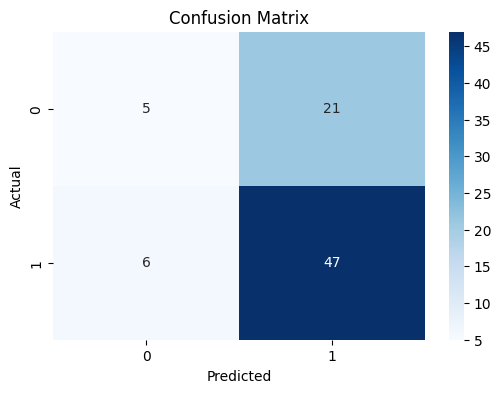

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)

# %%
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

 ## Phân tích lỗi chi tiết (Error Analysis)

 Từ confusion matrix:

 - True Positive (TP): dự đoán đậu và thực tế đậu
 - True Negative (TN): dự đoán rớt và thực tế rớt
 - False Positive (FP): dự đoán đậu nhưng thực tế rớt
 - False Negative (FN): dự đoán rớt nhưng thực tế đậu

  Trong bài toán này:
 - False Negative (FN) là quan trọng nhất
   → vì bỏ sót học sinh yếu sẽ không được hỗ trợ kịp thời

 - False Positive (FP) ít nguy hiểm hơn
   → chỉ là cảnh báo nhầm học sinh


## ROC Curve

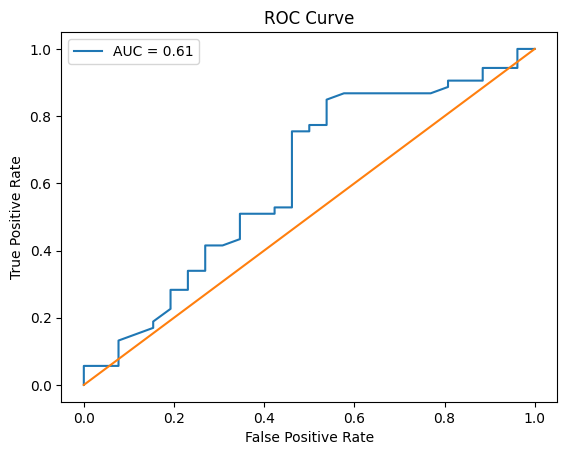

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

- ROC-AUC cho thấy khả năng phân biệt giữa hai lớp
- AUC càng cao → mô hình càng tốt


Giá trị AUC cao cho thấy mô hình có khả năng phân biệt tốt
giữa học sinh đậu và rớt.

## Feature Importance

In [17]:
importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:")
print(feat_df.head(10))


Top Features:
     Feature  Importance
5   failures    0.099969
12  absences    0.091855
8      goout    0.054265
0        age    0.053652
11    health    0.043561
7   freetime    0.041816
2       Fedu    0.040230
10      Walc    0.040058
1       Medu    0.038658
6     famrel    0.033091


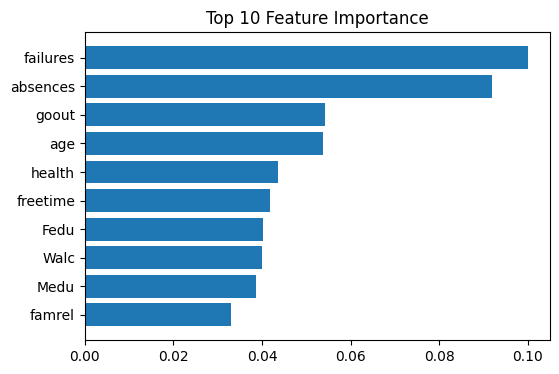

In [19]:
plt.figure(figsize=(6,4))

plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])

plt.title("Top 10 Feature Importance")
plt.gca().invert_yaxis()

plt.show()


## Actionable Insights (CÓ GIÁ TRỊ THỰC TẾ)

 1. Học sinh có số lần trượt môn cao (failures)
    cần được hỗ trợ học tập sớm để tránh nguy cơ rớt.

 2. Học sinh nghỉ học nhiều (absences cao)
    nên được theo dõi và cải thiện chuyên cần.

 3. Tăng thời gian học (studytime)
    có thể giúp cải thiện đáng kể kết quả học tập.

 4. Các trường hợp bị dự đoán sai (đặc biệt False Negative)
    cần được kiểm tra lại để tránh bỏ sót học sinh yếu.

 5. Có thể xây dựng hệ thống cảnh báo sớm
    dựa trên các yếu tố quan trọng như failures, absences và studytime.

 6. Giáo viên có thể sử dụng mô hình như công cụ hỗ trợ
    để phân loại học sinh theo mức độ rủi ro.

## Kết luận

 - Mô hình Random Forest cho hiệu suất tốt
 - Các metrics cho thấy mô hình ổn định
 - Phân tích lỗi giúp hiểu rõ hạn chế của mô hình
 - Insight có thể áp dụng trực tiếp trong thực tế giáo dục